In [3]:
%cd ..

/Users/juansegundohevia/Documents/neni/skill_scraping


In [1]:
import pandas as pd 
import numpy as np 
import json 
import matplotlib.pyplot as plt

In [18]:
import os


RESULTS_PATHS = [
    "data/jobs/job_data_20250501_2248_index0",
    "data/jobs/job_data_20250501_2321_index128",
]

def load_results(path):
    
    _path_results = []

    for res in os.listdir(path):
        if not res.endswith(".json"):
            continue
        
        try:
            with open(os.path.join(path, res), "r") as f:
                row_data = json.load(f)

            # add ID to row_data
            row_data["id"] = res.split(".")[0]
            # add path to row_data
            row_data["path"] = path

            _path_results.append(row_data)
        except Exception as e:
            print(f"Error loading {res}: {e}")
            continue

    return _path_results

data = []

for path in RESULTS_PATHS:
    path_results = load_results(path)
    data.extend(path_results)

df = pd.DataFrame(data)
df.info()
            

Error loading 01JT7KGHBVTE4V4216QZ8H67HC.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7KRE7F3GKM3Q5XJ2286DYR.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7KQAZCN2GG8RDS8EAJ4MHH.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7QAGQDXJXB7F4G2DAHQZ02.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7RK2F3MZ6Y76TGQ67VQKXH.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7SAAHB8TJATTWWDJCFHYXT.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7SFN10MNTA3ECT9NWXR4ER.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7NT7DSC697338X35FHW0J1.json: Expecting value: line 1 column 1 (char 0)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674 entries, 0 to 673
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        674 non-null    object
 1   company      674 non-null    object
 2   location     6

In [19]:
# explode the skills column
skills_data = df.explode("skills", ignore_index=True).copy()

In [20]:
# preprocess the "skills" column, which is a dictionary
skills_data["skill_name"] = skills_data.skills.apply(lambda x: list(x.values())[0] if isinstance(x, dict) else x)
skills_data["skill_motive"] = skills_data.skills.apply(lambda x: list(x.values())[1] if isinstance(x, dict) else x)

# drop the original "skills" column
skills_data.drop(columns=["skills",
                          "md_text",
                          ], inplace=True)

skills_data.info()
# check the first few rows
skills_data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3341 entries, 0 to 3340
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         3341 non-null   object
 1   company       3341 non-null   object
 2   location      3341 non-null   object
 3   description   3341 non-null   object
 4   mode          3341 non-null   object
 5   seniority     3341 non-null   object
 6   url           3341 non-null   object
 7   id            3341 non-null   object
 8   path          3341 non-null   object
 9   skill_name    3341 non-null   object
 10  skill_motive  3341 non-null   object
dtypes: object(11)
memory usage: 287.2+ KB


,title,company,location,description,mode,seniority,url,id,path,skill_name,skill_motive
0,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Experiencia comercial,Es esencial para identificar y satisfacer las ...
1,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Ventas del rubro automotriz,Valiosa para comprender el mercado y ofrecer u...
2,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Venta telefónica,Importante para la captación de clientes y gen...
3,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Call center,Habilidad necesaria para manejar consultas y c...
4,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Excel intermedio,Es necesario para gestionar datos y análisis e...
5,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Conocimiento de canales de venta digital,Requerido para brindar soporte y manejo adecua...
6,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Gestión de contingencias operativas,Importante para garantizar términos de planifi...
7,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Proactividad y flexibilidad,Valioso para adaptarse a un entorno dinámico y...
8,Recepcionista,Importante cadena de Farmacias,"San Martin, Buenos Aires, Argentina","Buscamos una persona organizada, proactiva, co...",presencial,junior,https://bumeran.com.ar/empleos/recepcionista-g...,01JT7JHFC55SC1ZAN0VCTFZX85,data/jobs/job_data_20250501_2248_index0,Atención al cliente,Es esencial para recibir y guiar a los cliente...
9,Recepcionista,Importante cadena de Farmacias,"San Martin, Buenos Aires, Argentina","Buscamos una persona organizada, proactiva, co...",presencial,junior,https://bumeran.com.ar/empleos/recepcionista-g...,01JT7JHFC55SC1ZAN0VCTFZX85,data/jobs/job_data_20250501_2248_index0,Comunicación verbal,Se requiere para mantener un trato amable y co...


# Compute Embeddings

In [22]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("nomic-ai/modernbert-embed-base", truncate_dim=256)

In [25]:
merged_skill_data = skills_data.skill_name.str.cat(skills_data.skill_motive, sep=" - ")
merged_skill_data[0]

'Experiencia comercial - Es esencial para identificar y satisfacer las necesidades de los clientes en el sector automotriz.'

# Try embedding just the name

In [27]:
names = skills_data.skill_name.copy().tolist()
names[:3]

['Experiencia comercial', 'Ventas del rubro automotriz', 'Venta telefónica']

In [28]:
name_embs = model.encode(names, show_progress_bar=True, device="mps")

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

In [30]:
type(name_embs), name_embs.shape

(numpy.ndarray, (3341, 256))

#### Compute clusters with KMeans

In [43]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [49]:
MAX_CENTERS = 50
NUM_CENTERS = np.arange(4, MAX_CENTERS, step=2)

def compute_kmeans(X, n_clusters):
    _x = X.copy() # make a copy of the data to avoid modifying the original

    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        init="k-means++",
        batch_size=64)
    
    kmeans.fit(_x)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    inertia = kmeans.inertia_
    silhouette = silhouette_score(_x, labels)
    return labels, centers, inertia, silhouette

res = compute_kmeans(name_embs, 5)

In [52]:
from tqdm import tqdm

PCA_COMPONENTS = 20
_x = name_embs.copy() # make a copy of the data to avoid modifying the original

# compute PCA
if PCA_COMPONENTS is not None:
    pca = PCA(n_components=PCA_COMPONENTS)
    _x = pca.fit_transform(_x)
    print(f"Explained variance: {np.sum(pca.explained_variance_ratio_)}")


# compute kmeans for all centers
kmeans_results = []
for n_centers in tqdm(NUM_CENTERS):

    labels, centers, inertia, silhouette = compute_kmeans(_x, n_centers)
    kmeans_results.append({
        "n_centers": n_centers,
        "labels": labels,
        "centers": centers,
        "inertia": inertia,
        "silhouette": silhouette
    })
# convert to dataframe
kmeans_df = pd.DataFrame(kmeans_results)

Explained variance: 0.5105770230293274


100%|██████████| 23/23 [00:01<00:00, 12.50it/s]


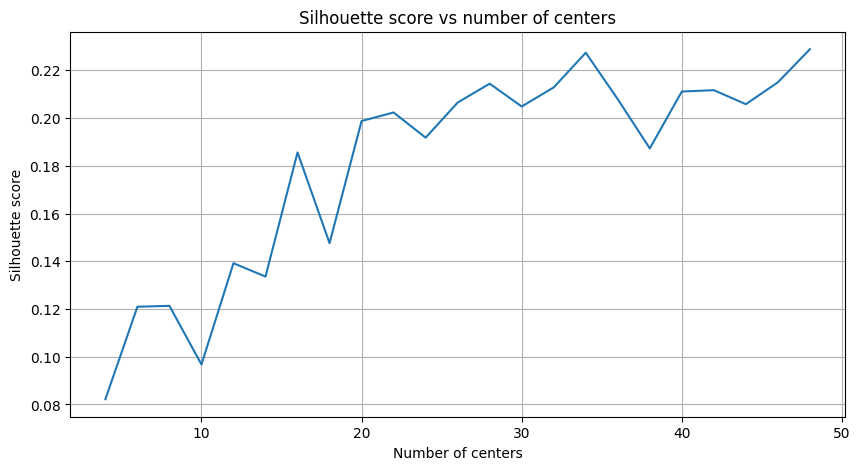

In [53]:
# plot silhouette score
plt.figure(figsize=(10, 5))
plt.plot(kmeans_df.n_centers, kmeans_df.silhouette)
plt.xlabel("Number of centers")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs number of centers")
plt.grid()

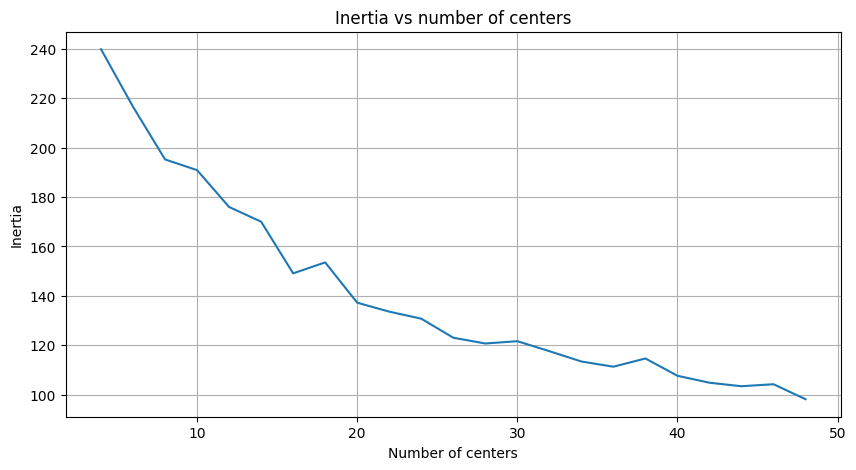

In [58]:
kmeans_df.sort_values("n_centers", inplace=True)

# plot inertia
plt.figure(figsize=(10, 5))
plt.plot(kmeans_df.n_centers, kmeans_df.inertia)
plt.xlabel("Number of centers")
plt.ylabel("Inertia")
plt.title("Inertia vs number of centers")
plt.grid()
plt.show()

In [65]:
kmeans_df.sort_values("silhouette", ascending=False, inplace=True)
kmeans_df.head(20)

,n_centers,labels,centers,inertia,silhouette
22,48,"[44, 36, 36, 32, 21, 38, 33, 31, 24, 8, 29, 32...","[[-0.030238396, 0.14291428, -0.066811174, 0.01...",98.131851,0.228822
15,34,"[22, 10, 10, 9, 21, 2, 24, 20, 6, 32, 15, 1, 6...","[[-0.0033061896, -0.018947992, 0.068285316, -0...",113.409172,0.227356
21,46,"[42, 18, 18, 20, 4, 35, 43, 38, 11, 13, 1, 20,...","[[-0.1487452, -0.037259366, -0.053983122, -0.0...",104.206223,0.214970
12,28,"[16, 1, 1, 21, 22, 2, 24, 7, 23, 3, 19, 25, 23...","[[-0.024066601, -0.033073727, 0.03603571, 0.02...",120.699524,0.214392
14,32,"[26, 5, 6, 20, 17, 28, 24, 16, 4, 21, 18, 20, ...","[[0.0522267, 0.201276, 0.105976775, -0.2231672...",117.591629,0.212836
19,42,"[15, 3, 3, 29, 1, 7, 25, 12, 11, 13, 29, 18, 1...","[[-0.060965173, -0.01806515, 0.030708903, -0.0...",104.810661,0.211667
18,40,"[10, 34, 34, 25, 31, 29, 20, 36, 13, 28, 15, 2...","[[-0.104719624, -0.15770222, 0.05606879, -0.07...",107.623169,0.211097
16,36,"[8, 2, 5, 21, 0, 34, 22, 26, 17, 7, 19, 21, 17...","[[0.16505896, -0.07737538, 8.384718e-05, 0.008...",111.300552,0.207872
11,26,"[15, 9, 19, 5, 17, 25, 7, 14, 12, 20, 5, 22, 1...","[[-0.017663565, -0.033706706, 0.030990588, 0.0...",123.037247,0.206487
20,44,"[35, 12, 38, 25, 0, 41, 9, 26, 21, 18, 36, 11,...","[[0.15170853, -0.075339146, 0.0036927955, 0.00...",103.390373,0.205789


In [ ]:
TARGET_CENTER = 16
# fit the kmeans model with the best silhouette score
kmeans = MiniBatchKMeans(
    n_clusters=TARGET_CENTER,
    init="k-means++",
    batch_size=64)
kmeans.fit(_x)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# assign the labels to the original data
clustered_data = skills_data.copy()
clustered_data["cluster"] = labels
clustered_data["cluster"] = clustered_data["cluster"].astype(str)

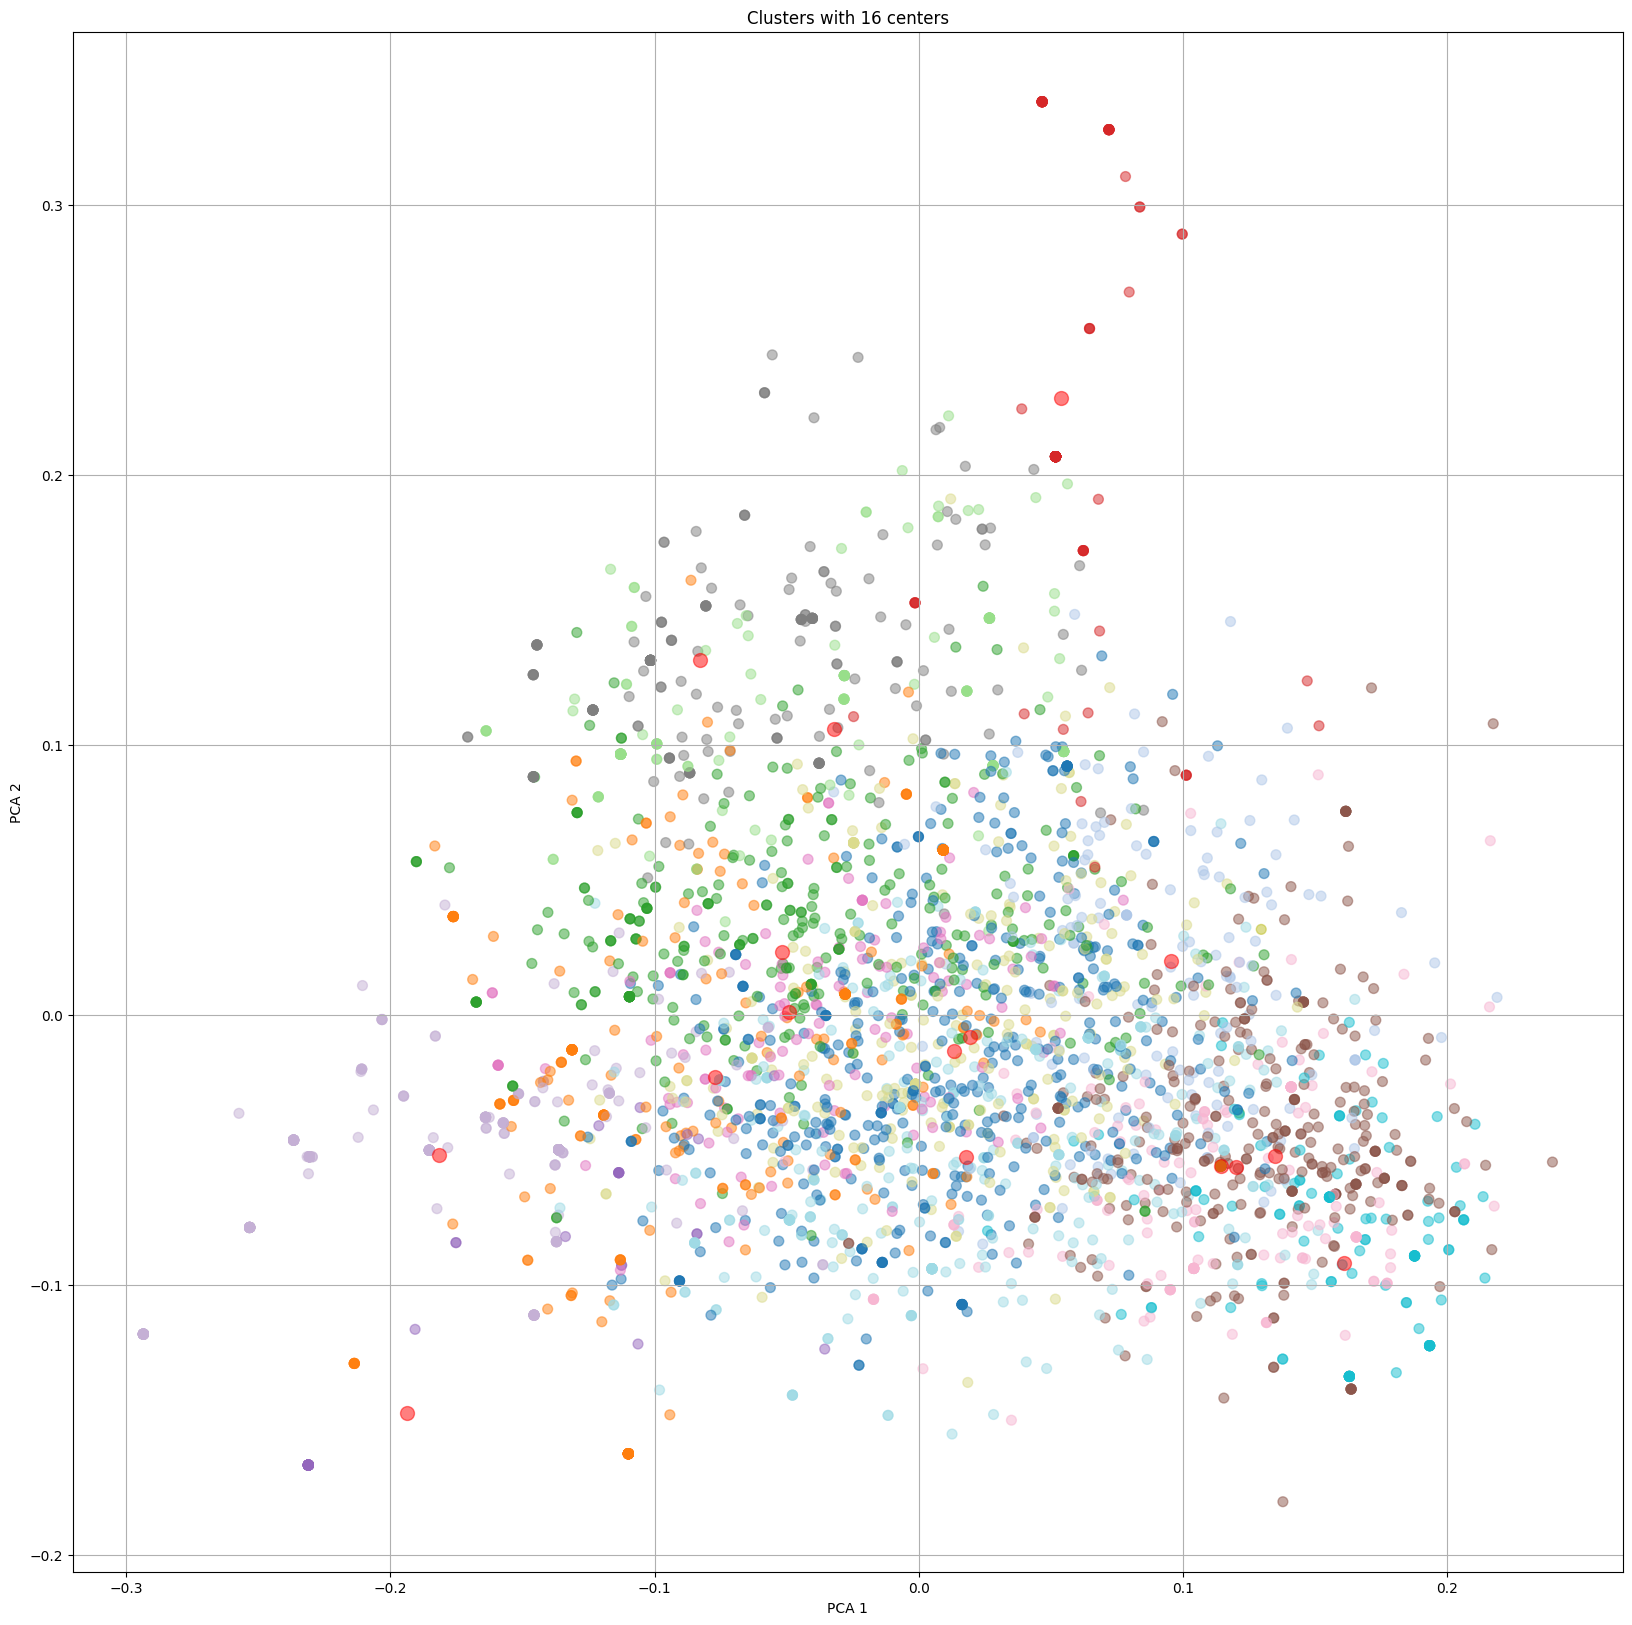

In [67]:
# visualize the clusters
# transform to 2D using PCA
_plot_pca = PCA(n_components=2).fit(_x)
_plot_x = _plot_pca.transform(_x)
_centers = _plot_pca.transform(centers)

plt.figure(figsize=(20,20))
plt.scatter(_plot_x[:, 0], _plot_x[:, 1], c=labels, s=50, cmap="tab20", alpha=0.5)
plt.scatter(_centers[:, 0], _centers[:, 1], c="red", s=100, alpha=0.5)
plt.title(f"Clusters with {TARGET_CENTER} centers")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid()

In [82]:
# get sample results from each cluster
# idx_cls = np.random.choice(clustered_data.cluster.unique())
idx_cls = "2"

sample_results = clustered_data[clustered_data.cluster == idx_cls].sample(10)

print(f"Cluster: {idx_cls}")
# print skill name for each sample result
for i, row in sample_results.iterrows():
    print(f"Skill name: {row.skill_name} - {row.skill_motive}")

Cluster: 2
Skill name: Buena presentación personal - Representa la imagen del negocio y es importante para el trato con los clientes.
Skill name: Resolución de problemas - Importante para manejar situaciones adversas y encontrar soluciones rápidas.
Skill name: Proactividad - Es fundamental para liderar proyectos y mantener la motivación del equipo.
Skill name: Proactividad - Permite anticiparse a las necesidades del cliente y proponer soluciones.
Skill name: Proactividad - El candidato necesita tomar la iniciativa en las tareas para contribuir al correcto funcionamiento operativo.
Skill name: Proactividad - Es necesaria para anticipar problemas y tomar la iniciativa en la resolución de los mismos.
Skill name: Elaboración de pastas - Se requiere al menos 5 años de experiencia en la elaboración de pastas para asegurar la calidad del producto.
Skill name: Actitud proactiva - Es fundamental para identificar oportunidades de venta y cerrar acuerdos exitosos.
Skill name: Proactividad - Permi

Algunos clusters que vi:

7 - comunicación interpersonal

11 - computación y análisis (Excel, PC)

2 - soft skills / proactividad

In [83]:
# consolidate all functions
def test_centers(X, n_centers, pca_components=None):
    """
    Test different number of centers for kmeans clustering
    """
    # make a copy of the data to avoid modifying the original
    _x = X.copy()

    # compute PCA
    if pca_components is not None:
        pca = PCA(n_components=pca_components)
        _x = pca.fit_transform(_x)
        print(f"Explained variance: {np.sum(pca.explained_variance_ratio_)}")

    # compute kmeans for all centers
    kmeans_results = []
    for n_centers in tqdm(n_centers):
        labels, centers, inertia, silhouette = compute_kmeans(_x, n_centers)
        kmeans_results.append({
            "n_centers": n_centers,
            "labels": labels,
            "centers": centers,
            "inertia": inertia,
            "silhouette": silhouette
        })
    
    return pd.DataFrame(kmeans_results)

def plot_silhouette(kmeans_df):
    """
    Plot silhouette score vs number of centers
    """
    plt.figure(figsize=(10, 5))
    plt.plot(kmeans_df.n_centers, kmeans_df.silhouette)
    plt.xlabel("Number of centers")
    plt.ylabel("Silhouette score")
    plt.title("Silhouette score vs number of centers")
    plt.grid()

def plot_inertia(kmeans_df):
    """
    Plot inertia vs number of centers
    """
    plt.figure(figsize=(10, 5))
    plt.plot(kmeans_df.n_centers, kmeans_df.inertia)
    plt.xlabel("Number of centers")
    plt.ylabel("Inertia")
    plt.title("Inertia vs number of centers")
    plt.grid()

def plot_clusters(X, labels, centers):
    """
    Plot clusters
    """
    # transform to 2D using PCA
    _plot_pca = PCA(n_components=2).fit(X)
    _plot_x = _plot_pca.transform(X)
    _centers = _plot_pca.transform(centers)

    plt.figure(figsize=(20,20))
    plt.scatter(_plot_x[:, 0], _plot_x[:, 1], c=labels, s=50, cmap="tab20", alpha=0.5)
    plt.scatter(_centers[:, 0], _centers[:, 1], c="red", s=100, alpha=0.5)
    plt.title(f"Clusters with {len(centers)} centers")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid()

def get_sample_results(clustered_data, cluster_id, n_samples=10):
    """
    Get sample results from each cluster
    """
    sample_results = clustered_data[clustered_data.cluster == cluster_id].sample(n_samples)
    print(f"Cluster: {cluster_id}")
    # print skill name for each sample result
    for i, row in sample_results.iterrows():
        print(f"Skill name: {row.skill_name} - {row.skill_motive}")

# Let's try with name + description

In [84]:
name_desc = skills_data.skill_name.str.cat(skills_data.skill_motive, sep=" - ")
name_desc_embs = model.encode(name_desc, show_progress_bar=True, device="mps")
name_desc_embs.shape

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

(3341, 256)

In [103]:
kmeans_df_namedesc = test_centers(name_desc_embs, NUM_CENTERS, pca_components=20)

Explained variance: 0.48061832785606384


100%|██████████| 23/23 [00:01<00:00, 12.53it/s]


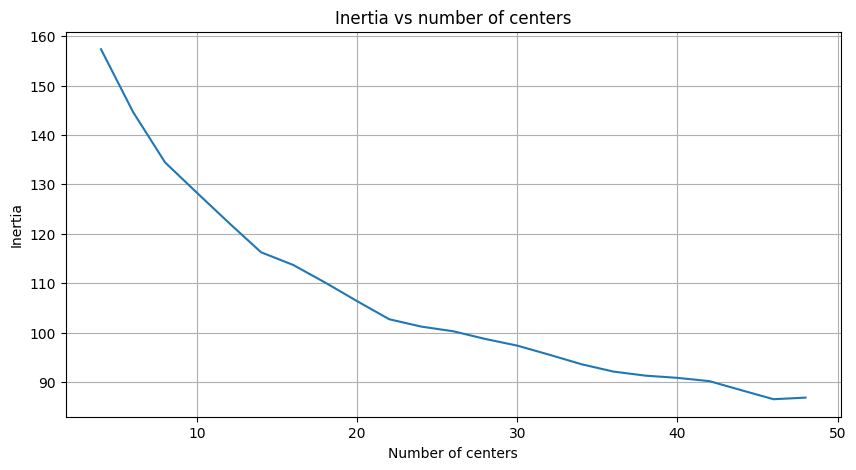

In [104]:
plot_inertia(kmeans_df_namedesc)

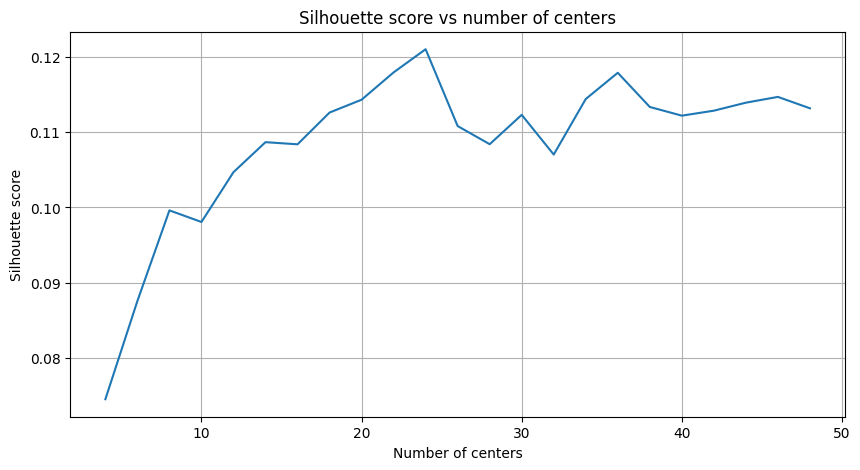

In [105]:
plot_silhouette(kmeans_df_namedesc)

In [107]:
kmeans_df_namedesc.sort_values("silhouette", ascending=False, inplace=True)
kmeans_df_namedesc.head(10)

,n_centers,labels,centers,inertia,silhouette
10,24,"[19, 6, 16, 11, 15, 3, 17, 9, 16, 0, 21, 10, 1...","[[-0.109274425, -0.120210975, 0.051420424, 0.0...",101.224541,0.121046
9,22,"[1, 16, 10, 10, 3, 16, 7, 5, 10, 2, 7, 5, 10, ...","[[0.04819867, -0.031640526, 0.061101004, -0.03...",102.712845,0.117961
16,36,"[4, 6, 10, 35, 21, 6, 22, 11, 10, 14, 0, 18, 1...","[[0.027541079, -0.016656356, -0.037849713, -0....",92.120354,0.117910
21,46,"[1, 3, 3, 20, 16, 3, 31, 43, 11, 18, 24, 28, 1...","[[0.057973612, -0.051650602, -0.03472353, -0.0...",86.529282,0.114702
15,34,"[1, 23, 16, 15, 10, 23, 32, 20, 16, 18, 9, 11,...","[[0.08140311, -0.08766833, -0.01668586, 0.0505...",93.614098,0.114422
8,20,"[10, 15, 15, 19, 9, 15, 7, 12, 17, 6, 12, 12, ...","[[0.02818847, 0.019495053, -0.0650545, 0.01238...",106.359955,0.114328
20,44,"[11, 12, 4, 5, 30, 4, 26, 35, 16, 33, 13, 28, ...","[[-0.12365413, -0.13587938, 0.01851341, 0.0020...",88.344383,0.113933
17,38,"[22, 1, 20, 20, 37, 21, 32, 15, 27, 23, 0, 15,...","[[0.02736243, -0.043416034, -0.06373796, -0.03...",91.302231,0.113363
22,48,"[3, 47, 24, 35, 5, 24, 20, 46, 21, 16, 37, 37,...","[[-0.05564464, 0.08310027, 0.028696539, 0.0347...",86.853302,0.113186
19,42,"[8, 22, 21, 30, 29, 22, 20, 28, 24, 21, 41, 2,...","[[-0.17493446, -0.104260735, -0.008884263, 0.0...",90.185989,0.112868


In [126]:
TARGET_CENTER = 10
# fit the kmeans model with the best silhouette score
kmeans_namedesc = MiniBatchKMeans(
    n_clusters=TARGET_CENTER,
    init="k-means++",
    batch_size=64)
kmeans_namedesc.fit(name_desc_embs)
labels_namedesc = kmeans_namedesc.labels_
centers_namedesc = kmeans_namedesc.cluster_centers_
# assign the labels to the original data
clustered_data_namedesc = skills_data.copy()
clustered_data_namedesc["cluster"] = labels_namedesc

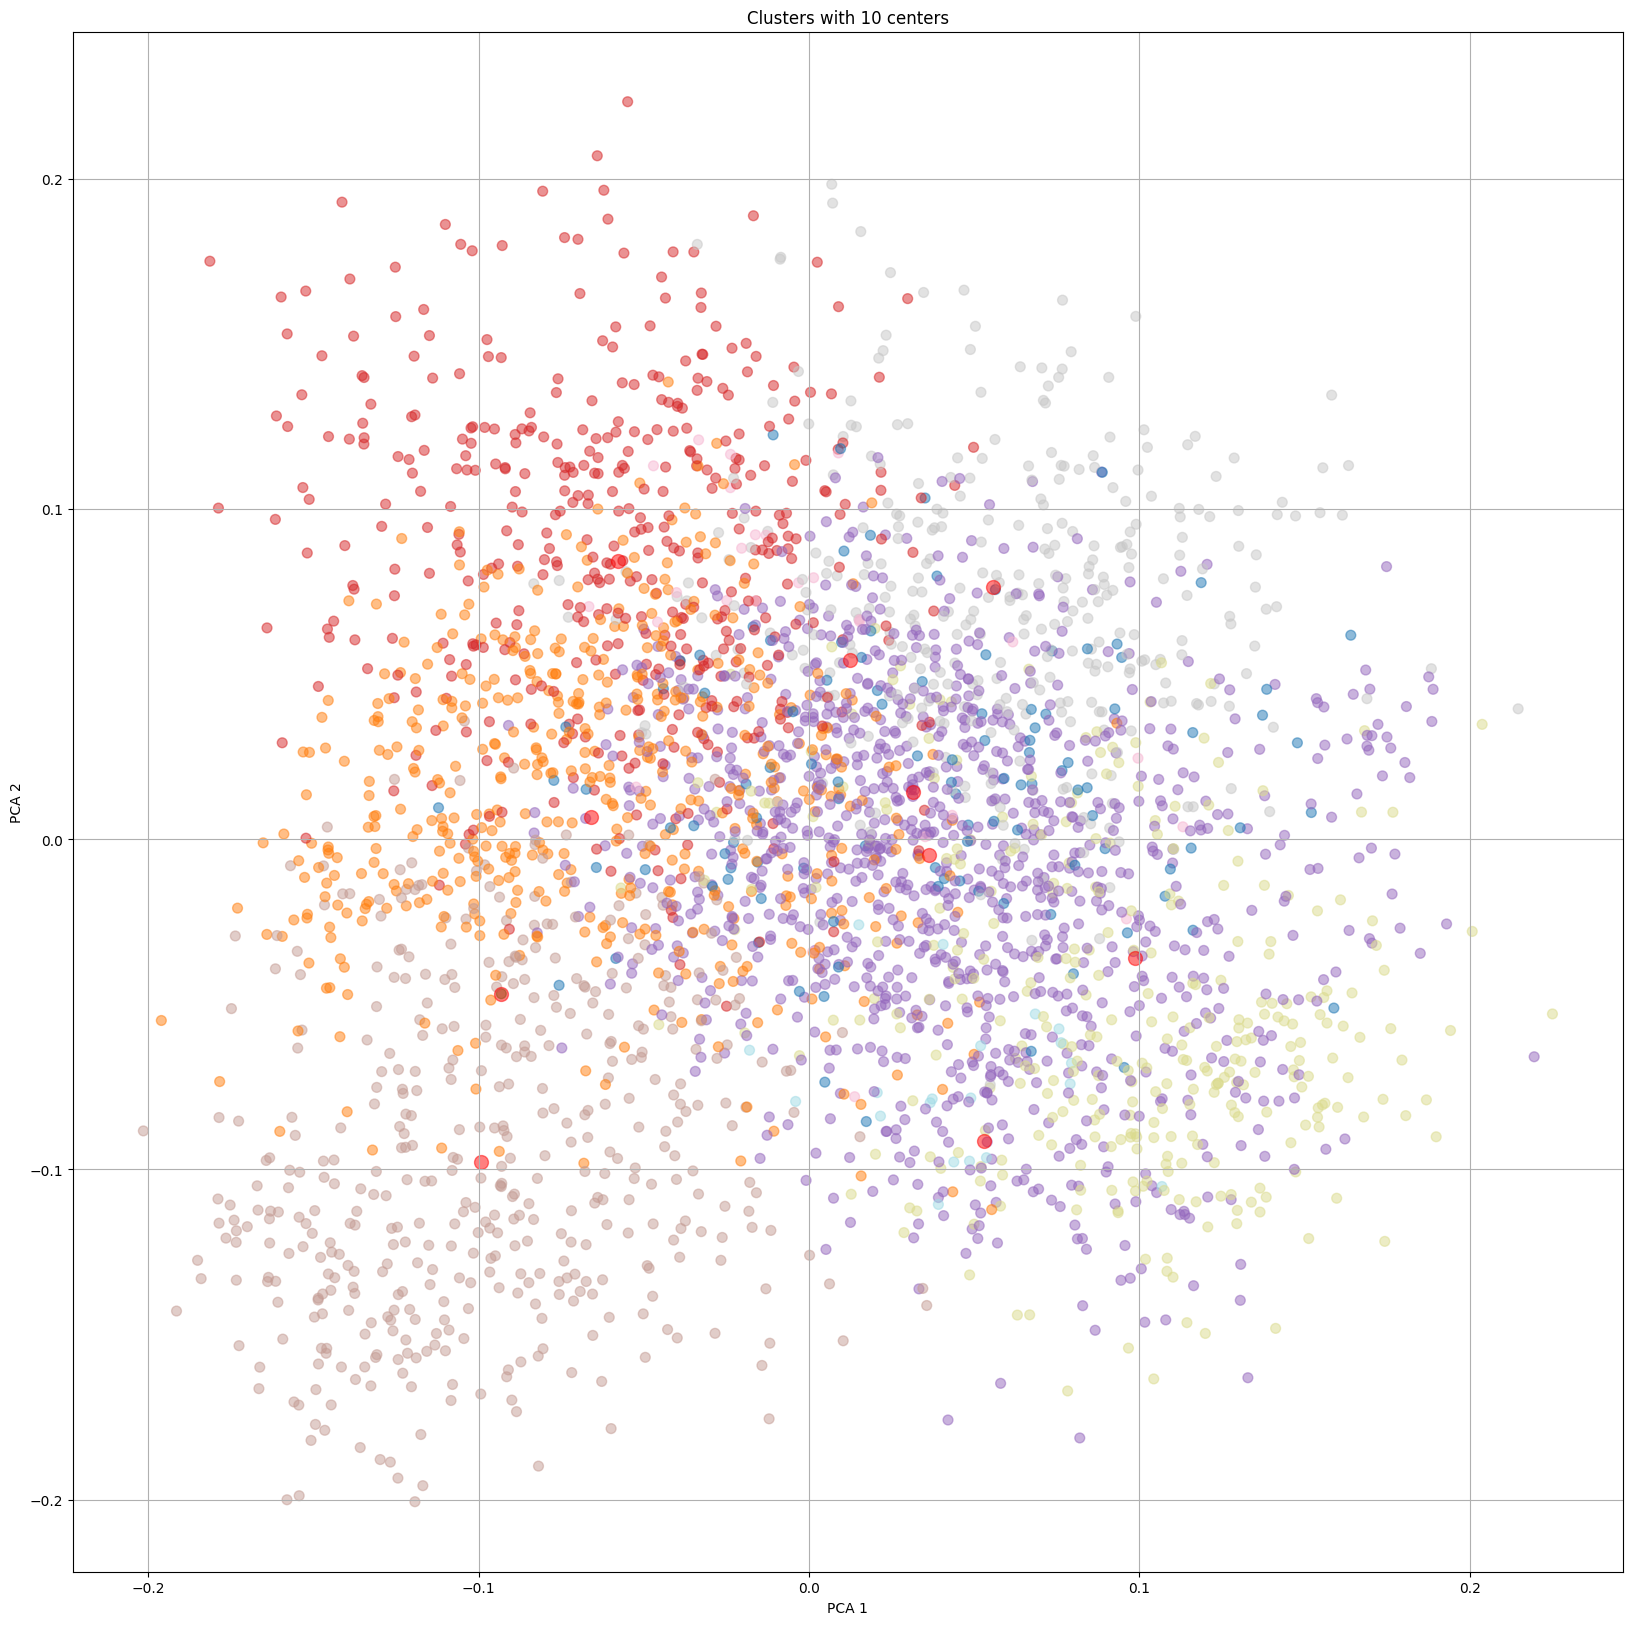

In [127]:
plot_clusters(name_desc_embs, labels=labels_namedesc, centers=centers_namedesc)

In [157]:
# get sample results from each cluster
idx_cls = np.random.choice(clustered_data_namedesc.cluster.unique())

sample_results_namedesc = clustered_data_namedesc[clustered_data_namedesc.cluster == idx_cls].copy()
_max_pop = len(sample_results_namedesc)
sample_results_namedesc = sample_results_namedesc.sample(np.min([15, _max_pop]), replace=False)

print(f"Cluster: {idx_cls}")
# print skill name for each sample result
for i, row in sample_results_namedesc.iterrows():
    print(f"Skill name: {row.skill_name} - {row.skill_motive}")

Cluster: 3
Skill name: Excelentes habilidades de conducción - Se requiere para desempeñar adecuadamente las tareas de un chofer.
Skill name: Experiencia en logística - Es esencial para realizar tareas como recepción, picking, empaquetado y despacho.
Skill name: Licenciado/a en Enfermería - Es un requisito esencial para cumplir con las funciones del puesto y para la obtención de la matrícula nacional.
Skill name: Experiencia con elementos de medición - Importante para el control de calidad y calibración de equipos.
Skill name: Excelente presencia - Importante para el trabajo de ventas en el sector cosmético.
Skill name: Experiencia en el área comercial - Es necesaria para asegurar que el candidato tenga un buen entendimiento y habilidades en ventas.
Skill name: Experiencia en media y baja tensión - Es fundamental para realizar tareas de instalación y mantenimiento adecuadas.
Skill name: Experiencia en el sector gastronómico - Es esencial debido a que el candidato debe tener amplio conoc

C8 Gestión Financiera

C4 Fuzzy - Gestión y Soporte Operativo

C9 Contabilidad

C3 Experiencia como requerimiento

C7 Fuzzy - Habilidades de industria pesada (textil, metalurgia, pintura)

C6 Ventas

C5 Habilidades interpersonales

C0 Gestión de inventarios y operación comercial

C1 Liderazgo

C2 NaN